> This is the 4th chapter of the LLM from Scratch Book. This chapter covers :
- Coding a GPT-like large language model (LLM) that can be trained to generate human-like text
- Normalizing layer activations to stabilize neural network training
- Adding shortcut connections in deep neural networks to train models more effectively
- Implementing transformer blocks to create GPT models of various sizes
- Computing the number of parameters and storage requirements of GPT models

![Alt Text](pics/LLM_Architecture_Mental_Model.png)

> Mental Model of a GPT like Architecture

![Alt Text](pics/GPT_MentalModel.png)

- In this Chapter we are going to scaling up to the size of a small GPT-2 model, specifically the smallest version with 124 million  parameters, as described in Radford et al.'s paper, "Language Models are Unsupervised Multitask Learners.

In [1]:
import torch
import torch.nn as nn

In [2]:
#Here we specify the configuration of the GPT-2 Model we will work on.
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers i.e specifies the number of transformer blocks in the model
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

![Alt Text](pics/GPT_ArchitectureRemaining.png)

### Creating A placeholder Dummy GPT model architecture class

In [13]:
#Here we specify the configuration of the GPT-2 Model we will work on.
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers i.e specifies the number of transformer blocks in the model
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

In [3]:
#Placeholder Classes.
#A simple placeholder class that will be replaced by a real TransformerBlock later
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x


#A simple placeholder class that will be replaced by a real LayerNorm later
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x

In [4]:
#Now first we will create a place holder class for the transformer block and the gradually add the components.
#In this GPT-2 DummyClass we will have the token Embedding creation in the class itself unlike MHA is previous one where token embeddings were coming from outside and we were just calculating the Attention.
# A placeholder GPT model architecture class
class DummyGPTModel(nn.Module):

    """This Dummy GPT Model does the whole Pipeline as Follows:
        1. First it takes a batch of Token Ids and then converts it to Token Embeddings.
        2. Then Creates the Positional Embeddings for the batch of INputs based on the Seq_len
        3. Then its adds them to get the Input to the Transformer Model.
        4. Next we have multiple layers of Transformer Models which take this Batch of Vectorized Inut Sequnece in form like (batch, seq_len, input_embed)
        5. Then we do Layer Norm after the Transformer Block.
        6. Then there is a Linear Projection Layer from Embedding_Dim -> Vocab_Size to get the logits.Here we can apply a Softmax to get the Prob. Distribution across the Tokens Vocab.
        """

    def __init__(self, cfg):
        super().__init__()

        self.token_emb = nn.Embedding(num_embeddings=cfg['vocab_size'], embedding_dim=cfg['emb_dim'])
        self.pos_emb  = nn.Embedding(num_embeddings=cfg['context_length'], embedding_dim=cfg['emb_dim'])

        #Using the Dummy Transformer class where we are stacking num_layers of transformer blocks to run sequentially.
        self.transformer_layer = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )
        #Using the Dummy LayerNorm Class
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])

        #At last project to the size of vocab_size across all tokens to get the logit value(but not the logistic one here) for all tokens.
        self.out_head = nn.Linear(in_features=cfg['emb_dim'], out_features=cfg['vocab_size'])


    def forward(self, in_idx):

        #in_idx is a batch of input token_ids, so in_idx-> (batch, seq_len) like tensor([23,45,67]) is a input_seq of token_ids
        batch_size, seq_len = in_idx.shape   
        #Now we get the intialized embeddings of the token_ids based on its position_idx from the nn.Embedding matrix.
        token_embeddings = self.token_emb(in_idx) #(batch, seq_len) -> (batch, seq_len, cfg['emb_dim'])
        #Now we get the positional embeddings for all the position indexes from 0 to seq_len.
        pos_embeddings = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = token_embeddings + pos_embeddings
        x = self.drop_emb(x)
        x = self.transformer_layer(x)
        x = self.final_norm(x)
        logits = self.out_head(x)

        return  logits

In [10]:
#Using the DummyGPTModel.
import tiktoken

batch = []
tokenizer = tiktoken.get_encoding('gpt2')

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
print(batch)

[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]


In [12]:
batch = torch.stack(batch, dim=0)
print(f"Batch:{batch}\nShape:{batch.shape}")

Batch:tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Shape:torch.Size([2, 4])


In [15]:
torch.manual_seed(123)
dummy_gpt = DummyGPTModel(cfg=GPT_CONFIG_124M)
logits = dummy_gpt(batch)

print(logits)
print(logits.shape)

tensor([[[-1.0612,  0.1768, -0.8529,  ..., -0.9608, -0.1894, -0.4422],
         [ 0.2559,  0.6943, -0.1255,  ..., -0.7367,  1.2559,  0.5946],
         [ 0.8378,  1.4459, -0.1935,  ...,  1.4067, -0.1898,  0.6553],
         [ 0.3619,  1.7019, -0.7654,  ...,  1.0078,  0.1737, -0.5090]],

        [[-0.9291, -0.0768, -1.1879,  ..., -1.7291, -0.0162, -0.5473],
         [-0.8998,  0.4216,  0.3275,  ..., -0.2179, -0.0347,  1.5403],
         [ 0.8502,  1.3808, -0.3624,  ..., -0.6149,  0.0041, -0.1117],
         [ 0.8021, -0.6556,  0.5620,  ...,  1.9586, -0.1310,  0.3240]]],
       grad_fn=<ViewBackward0>)
torch.Size([2, 4, 50257])


![Alt Text](pics/GPTModel_Overview.png)

### 4.2 Normalizing activations with layer normalization

- So here we will try to Implement the LayerNorm Class.

![Alt Text](pics/LayerNorm_Illustration.png)

In [16]:
#Let's implement a simple layer norm.
torch.manual_seed(123)
batch_example = torch.rand(size=(2,5))
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
output = layer(batch_example)

print(f"Example Output:{output}\nShape:{output.shape}")

Example Output:tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)
Shape:torch.Size([2, 6])


![Alt Text](pics/dim_parameter_illustration.png)

In [ ]:
#Let's check the mean and var of the output for each of the 2 inputs in our batch.
mean = output.mean(dim=-1, keepdim=True)
var = output.var(dim=-1, keepdim=True)

print(f"Current Batch example Mean:{mean}\nVar:{var}")

#Normalizing the Output.
norm_output = (output - mean) / torch.sqrt(var) 
norm_mean = norm_output.mean(dim=-1, keepdim=True)  #KeepDIm=True makes the output keep the collapsed dimension even if we are aggregating.
norm_var = norm_output.var(dim=-1, keepdim=True)
print(f"\n\nNormalized Batch example Mean:{norm_mean}\nVar:{norm_var}")

Current Batch example Mean:tensor([[0.2432],
        [0.1928]], grad_fn=<MeanBackward1>)
Var:tensor([[0.0799],
        [0.0670]], grad_fn=<VarBackward0>)


Normalized Batch example Mean:tensor([[ 5.9605e-08],
        [-2.9802e-08]], grad_fn=<MeanBackward1>)
Var:tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


In [21]:
#We can see that Mean even after Normalization is not zero rather very small number like 5 * 10-8 and all because of precision error.
#To roundoff we can do 
torch.set_printoptions(sci_mode=False)
print(f"\n\nNormalized Batch example Mean:{norm_mean}\nVar:{norm_var}")



Normalized Batch example Mean:tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Var:tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


> Compact Class for LayerNormalization

In [3]:
class LayerNorm(nn.Module):

    """In LayerNorm we don\'t just normalize the laer but also add a trainable Scale(sigma) & SHift(mu) learnable Parameters.
        Reason:
        1. We initialze the parameters with same size as embedding_dim_size with 1's for Scale Parameter
        2. ANd for Shift we initialize with 0's and then let the network learn them as needed.
        Why: Because for training stability we can keep the information normalized but to restrict it to not learnable would be too restrictive.
        That is why the papers use learable Scale(lambda) & Shift(beta) Parameters.
        Final Form: If X is the Normalized Data then Output: lambda * X + beta"""

    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        #Nowe create the Parameters of size (embed_dim,) so we can use them as learnable paramtere and also boradcast with the whole input data.
        #But the scala & shift parameters work only on the embed_dim.
        self.scale = nn.Parameter(data=torch.ones(embed_dim))  #shape:(embed_dim,) so when multiplied elementwise boradcasted to (batch, num_token, embed_dim)
        self.shift = nn.Parameter(data=torch.zeros(embed_dim))

    def forward(self, x):

        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False) #We can have n-1 if unbiased=True for var but for huge embed dims n-1 or n doesn't matter as 

        norm_x = (x - mean) / torch.sqrt(var)

        #lambda * norm_x + beta = normalized(x)
        return  self.scale * norm_x + self.shift   #Here we are allowing the network to learn the scale & shift parameters if needed.



In [27]:
#Let's use the LayerNorm Class on our batch_example
ln = LayerNorm(embed_dim=5)
ln_output = ln(batch_example)

mean_ln_output = ln_output.mean(dim=-1, keepdim=True)
var_ln_output = ln_output.var(dim=-1, keepdim=True, unbiased=False)

print(f"Layer Normalized Class Output Mean:{mean_ln_output}\nVar:{var_ln_output}")

Layer Normalized Class Output Mean:tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Var:tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


> Also Checkou Layer Normalization vs Batch Normalization

### 4.3 Implementing a feed forward network with GELU activations

> There are two types of ACtiations used in GPT-2 other than Relu
- GELU : Gaussain Error Linear Unit,  GELU(x) = x⋅Φ(x), Here Φ(x) is cumulative distribution function of the standard Gaussian distribution.

- SwiGLU : (Swish-gated linear unit)

In GPT-2 they used an approximated version of GELU as the original is computationaly intensive.

![Alt Text](pics/GELU.png)

In [4]:
#In gpt-2 they used an approximated version of GELU as the original is computationaly intensive.
#GELU(x) = 
#GELU class.
class GELU(nn.Module):

    def __init__(self):
        super().__init__()
    def forward(self, x):
        gelu_x = 0.5 * x * (1+ torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi)) * 
            (x+ 0.044715 * torch.pow(x,3))
            ))
        return gelu_x
    

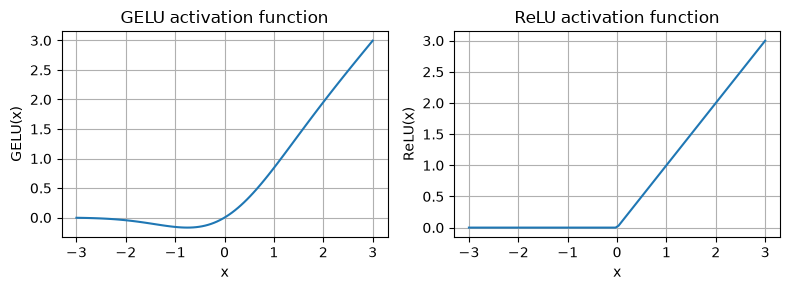

In [8]:
#Comparing the GELU and RELU
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
 plt.subplot(1, 2, i)
 plt.plot(x, y)
 plt.title(f"{label} activation function")
 plt.xlabel("x")
 plt.ylabel(f"{label}(x)")
 plt.grid(True)
plt.tight_layout()
plt.show()

> One can see that GELU is a differentiable function for Negative values as well unlike RELU which makes the -ve value to 0.

### 4.4 A Feed Forward Neural Network Module with GELU Activation

- Next, let’s use the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM’s transformer block later.

![Alt Text](pics/FFN_Illus1.png) 
![Alt Text](pics/FFN_Illus2.png)

In [5]:
#FFN class implementation.
class FeedForward(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        #Here now we creat a Two Linear Layers where in between we put a GELU ACtivation.
        #In Linear layers we want to project to higher dimension to learn the complex representation apply ACtivation and then bring it down to lower dimension.
        #Also We will use Sequential Here as we directly use th layers stack instead of tweaking in between results.
        self.layers = nn.Sequential(
            nn.Linear(in_features=cfg['emb_dim'], out_features= 4*cfg['emb_dim']),  #Projecting the embed_dim to 4 times 
            GELU(),
            nn.Linear(in_features=4*cfg['emb_dim'], out_features=cfg['emb_dim'])    #Then bringing it down to embed_dim
        )
    def forward(self, x):
        return self.layers(x)

In [11]:
#Let's use th FFN.
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(size=(2,3,768))  # Two batches of input with seq_len =3 and dimension 768
out_ = ffn(x)

print(out_)
print(out_.shape)

tensor([[[ 7.7862e-02, -1.0968e-01, -1.3944e-02,  ..., -2.3179e-01,
          -9.8540e-03, -8.4442e-02],
         [ 6.1821e-02, -7.5056e-03, -2.3453e-02,  ..., -8.7240e-02,
           4.9540e-02, -1.7343e-01],
         [ 1.0575e-01, -1.4111e-01, -9.6503e-02,  ..., -7.6500e-02,
          -7.1694e-03, -1.1886e-01]],

        [[-5.6358e-02,  1.8395e-05, -4.9702e-02,  ..., -2.0774e-02,
           1.0213e-01, -1.9671e-02],
         [ 1.4751e-01, -7.6328e-02, -2.3089e-02,  ..., -2.1301e-01,
          -1.6199e-02, -1.0028e-01],
         [ 1.2762e-01, -9.3649e-02, -1.2076e-02,  ..., -9.2093e-02,
           2.9978e-02, -9.0362e-02]]], grad_fn=<ViewBackward0>)
torch.Size([2, 3, 768])


### 4.4 Adding Shortcut /Skip Connections

![Alt Text](pics/SkipConnections_FFN.png)

In [3]:
class ExampleDeepNeuralNetwork(nn.Module):
    """Here we will implement a DNN/FFN with Skip Connections."""
    def __init__(self, layer_sizes, use_skip=True): #layer_sizes is a list of the dimension output we define like [3, 3, 3, 1]
        super().__init__()
        self.use_skip = use_skip
        #Here we are treating each Linear & GELU a single layer so we can apply Skip Connections after each of those operations and that's why used nn.Sequential() to bind them one after other.
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(in_features=layer_sizes[0], out_features=layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]))
        ])

    def forward(self, x):

        for layer in self.layers:
            layer_output = layer(x)

            if self.use_skip and x.shape == layer_output.shape: #In the last layer we map from (3,) to (1,) so here we will not have skip connection.
                x = layer_output + x
            else:
                x = layer_output

        return x


In [7]:
#Now let's use theExampleFFN wihtout skip
#Now here we use check that what happens to the loss when we use skip=False
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
 layer_sizes, use_skip=False
)

In [ ]:
def print_gradients(model, x):
    '''Function calculate the MSE Loss given Model & the Input , target is taken as Zero.'''
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()    #This thing calculates the loss gradient of the parameters.
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

> Network Without Skip Connections

- Here we can see that as we go from last layer i.e layer 4 to first layer i.e layer 0 the gradient are becoming too small.
- This is the problem of Vanishing Gradients which may cause no learning to first few layers if the Network becomes deep.

In [20]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0006289089797064662
layers.1.0.weight has gradient mean of 0.00037444636109285057
layers.2.0.weight has gradient mean of 0.0022296393290162086
layers.3.0.weight has gradient mean of 0.004360969644039869
layers.4.0.weight has gradient mean of 0.01574220508337021


> Network wih Skip Connections
- Here we can see the Loss Gradient at the First layers are no longer close to Zero and big enough for the First Layers to Learn.
- Also the graient value stabilizes as we progress towards the frist layer.
- These SHortCut/Skip Connections  helps us facilitate more effective training by ensuring consistent gradient flow across layers

In [12]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
 layer_sizes, use_skip=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.2527867257595062
layers.1.0.weight has gradient mean of 0.2359604835510254
layers.2.0.weight has gradient mean of 0.3751014769077301
layers.3.0.weight has gradient mean of 0.3039548695087433
layers.4.0.weight has gradient mean of 1.5117789506912231


### 4.5 Connecting attention and linear layers in a transformer block

> An Illustration of the Full Transformer Block
- Now, let’s implement the transformer block, a fundamental building block of GPT and
other LLM architectures. This block, which is repeated a dozen times in the 124-millionparameter GPT-2 architecture, combines several concepts we have previously covered:
multi-head attention, layer normalization, dropout, feed forward layers, and GELU
activations. Later, we will connect this transformer block to the remaining parts of the
GPT architecture.

![Alt Text](pics/TransformerBlock_Illus.png)

> First we will use the Masked MultiheadAttention Block from Previous Chapter.

In [6]:
#Causal MuliHeadAttention Class from Previous Chapter.
class MultiHeadAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.1, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, 'd_out must be divisible by num_heads'
        self.head_dim = d_out // num_heads
        self.num_heads = num_heads
        self.d_in, self.d_out, self.context_length = d_in, d_out, context_length

        self.W_q = nn.Linear(in_features=d_in, out_features=d_out, bias=qkv_bias)
        self.W_k = nn.Linear(in_features=d_in, out_features=d_out, bias=qkv_bias)
        self.W_v = nn.Linear(in_features=d_in, out_features=d_out, bias=qkv_bias)

        self.register_buffer(
            name='mask',
            tensor=torch.triu(input=torch.ones(size=(context_length, context_length)), diagonal=1)
        )

        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(in_features=d_out, out_features=d_out)

    def forward(self, x):

        #x or input is of shape (batch_size, seq_length, d_in)
        batch_size, num_tokens, d_in = x.shape
        Q, K, V = self.W_q(x), self.W_k(x), self.W_v(x)  #Using a Giant W_q/W_k/W_v matrix to create (batch_size, seq_length, d_in) ->(batch_size, seq_length, d_out)
        #Now we need to  the Giant matrices so that (batch_size, seq_length, d_out) becomes (batch_size, seq_length, num_heads, head_dim).
        Q = Q.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        K = K.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        V = V.view(batch_size, num_tokens, self.num_heads, self.head_dim)

        #Now we need to change calculate Attention for each block separately so first we have to interchange the num_tokens & num_heads place.
        Q, K, V = Q.transpose(1,2), K.transpose(1,2), V.transpose(1,2)  #Shape Output: (batch_size, num_heads,  num_tokens, head_dim)

        attn_scores = Q @ K.transpose(2,3)  #Output Shape: (batch_size, num_heads,  seq_length, seq_length)

        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )

        attn_weights = torch.softmax(attn_scores/(K.shape[-1]**0.5), dim=-1)  #(batch_size, num_heads,  num_tokens , num_tokens)
        attn_weights = self.dropout(attn_weights)

        context_vectors = attn_weights @ V  #Output Shape: (batch_size, num_heads,  num_tokens, head_dim)
        #Reversing the position of num_heads & num_tokens
        context_vectors =  context_vectors.transpose(1,2)  #Output Shape: (batch_size, num_tokens, num_heads, head_dim)

        #Now we need to make the current context_vector shape memory contiguus and then couple the num_heads & head_dim into one.

        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)  #Merged the num_heads & head_dim into d_out.

        context_vectors = self.out_proj(context_vectors)
        return context_vectors


> Now we Implement the Whole Transformer Block.

In [7]:
#Here we specify the configuration of the GPT-2 Model we will work on.
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers i.e specifies the number of Transformer blocks in the model
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

In [8]:
class TransformerBlock(nn.Module):
    """This class implments only the Transformer Block Part of th GPT Model.
        Follow the Illustration of the Transformer Block given above to implement it.
        Token , Positional , Linear Layer Projection are in different Blocks."""

    def __init__(self, cfg):
        super().__init__()
        self.CausalMultiHeadAttentionLayer = MultiHeadAttention(
            d_in = cfg['emb_dim'],
            d_out = cfg['emb_dim'],
            context_length = cfg['context_length'],
            num_heads = cfg['n_heads'],
            dropout = 0.1,
            qkv_bias = cfg['qkv_bias']
        )
        self.ffn = FeedForward(cfg)   #Using the FFN Layer we created in previous blocks
        self.norm1 = LayerNorm(embed_dim=cfg['emb_dim'])   #Using the LayerNorm Layer we created in previous blocks
        self.norm2 = LayerNorm(embed_dim=cfg['emb_dim'])
        self.dropout = nn.Dropout(cfg['drop_rate'])

    def forward(self, x):

        #Calling the x as shortcut connection.
        #Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.CausalMultiHeadAttentionLayer(x)
        x = self.dropout(x)
        x = x + shortcut

        #Shortcut connection for FFN block
        shortcut = x 
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + shortcut

        return x

In [22]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) 
trf_block = TransformerBlock(cfg=GPT_CONFIG_124M)
output = trf_block(x)
print(f"Output:{output}")
print(f'Shape:{output.shape}')

Output:tensor([[[-0.0056,  0.0972, -0.1122,  ...,  1.2890,  0.2623,  0.6685],
         [ 0.0023, -0.2369,  0.1720,  ...,  0.5952,  0.2497,  0.7447],
         [ 0.4672,  0.4472,  0.1791,  ...,  1.2526,  0.3045,  0.7750],
         [ 0.0662,  0.7224,  0.9206,  ...,  0.4790,  0.7428,  0.7016]],

        [[ 0.3622,  1.2144,  0.5221,  ...,  0.1854,  0.0111, -0.5035],
         [-0.0225,  0.7789,  0.2770,  ...,  0.1734,  0.5419,  0.1143],
         [ 0.7425,  0.4013,  0.3211,  ...,  0.3268,  0.7523, -0.1642],
         [ 0.5745,  0.6241,  0.4410,  ...,  1.1963,  1.2650,  0.2243]]],
       grad_fn=<AddBackward0>)
Shape:torch.Size([2, 4, 768])


### 4.6 Coding the Complete Decoder Part of GPT model

- Now here we will use the Transformer, LayerNorm Blocks we build in the above cells.

![Alt Text](pics/GPTModel_progression.png)

![Alt Text](pics/Complete_GPTModel.png)

> Description of the GPTModel Class:

- The **\__init\__()** constructor of this GPTModel class initializes the token and positional embedding layers using the configurations passed in via a Python dictionary, cfg. These embedding layers are responsible for converting input token indices into
dense vectors and adding positional information (see chapter 2).
- Next, the **\__init\__()** method creates a sequential stack of TransformerBlock modules equal to the number of layers specified in cfg. Following the transformer blocks, a LayerNorm layer is applied, standardizing the outputs from the transformer blocks to stabilize the learning process. Finally, a linear output head without bias is defined, which projects the transformer’s output into the vocabulary space of the tokenizer to generate logits for each token in the vocabulary.
- The **forward()** method takes a batch of input token indices, computes their embeddings, applies the positional embeddings, passes the sequence through the transformer blocks, normalizes the final output, and then computes the logits, representing the next
token’s unnormalized probabilities. We will convert these logits into tokens and text outputs in the next section. 

In [9]:
#Compact Implementation of the GPT(Decoder) Model Class
class GPTModel(nn.Module):

    """This is the Compact Class GPT Model (Note: GPT is a Decoder Only Transformer Model)
        Follow and use the above Image of the GPT Model to code the whole GPT Model."""

    def __init__(self, cfg):
        super().__init__()
        #token_embedding_generation.
        self.token_emb = nn.Embedding(num_embeddings=cfg['vocab_size'], embedding_dim=cfg['emb_dim'])
        #Since Context Length is Max Input length so our Architecture can handle at most this distant Tokens 
        #There are only <context_length> possible positions & So we need one vector for each possible position:
        #Why NOT vocab_size × emb_dim for positional embeddings?
        # Because position has nothing to do with which token is there. 
        # The position embedding for position 5 should be the same irrespective of which token it is.
        self.pos_emb = nn.Embedding(num_embeddings=cfg['context_length'], embedding_dim=cfg['emb_dim'])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )
        self.final_norm = LayerNorm(embed_dim=cfg['emb_dim'])
        self.dropout = nn.Dropout(p=cfg['drop_rate'])
        #Projection Layer Across the Vocab Size Dim.
        #PyTorch defines nn.Linear() Layer as: y = x @ W^T +b, So when we store W as nn.Linear(in_features=cfg['emb_dim'], out_features=cfg['vocab_size'])
        #W is stored as (50257, 768) even though we said (768, 50257) and internally when multiplied with x(batch_size, num_tokens, 768) they do (50257, 768).T i.e (batch_size, num_tokens, 768) @ (768, 50257).
        #So W_out_head can be thought of having same size of W_token_emb size.
        #Infact we can use the same Matrix for these things, which is called Weight Tying i.e to reuse the Token_Embedding Matrix in the Output Head as well.
        self.out_head = nn.Linear(in_features=cfg['emb_dim'], out_features=cfg['vocab_size'], bias=False)
        

    def forward(self, in_idx):  
        #in_dx is the token indices of a input like for a Input Every effort moves you -> Token Ids : [23,45,65,32,12]
        #Here after Tokenizing and encoding we pass these indices which the model takes and gives us the logits across the vocab_dim.
        #Then we take the max or use Beam Search or top K like techniques to get the token_ids and then from that get the decoded token from vocab_dict.
        
        batch_size, seq_length = in_idx.shape   #in_idx Shape: (batch_size, num_tokens)
        #Now let's get the token_embedings of the given token_indices.So we may get the embeddings of the token_ids of [23,45,65,32,12]
        #Making the shape from (batch_size, seq_length) to (batch_size, seq_length, emb_dim)
        token_embeddings = self.token_emb(in_idx)
        #We are getting the Positional Embedding from the Positions of the tokens starting from 0 to Seq_length for a Sequence.
        pos_embeddings = self.pos_emb(torch.arange(seq_length, device=in_idx.device))  #The device setting will allow us to train the model on a CPU or GPU, depending on which device the input data sits on. 

        x = token_embeddings + pos_embeddings #(batch_size, num_tokens, embed_dim)
        x = self.dropout(x)
        x = self.trf_blocks(x)  #(batch_size, num_tokens, embed_dim)
        x = self.final_norm(x)  #((batch_size, num_tokens, embed_dim))
        logits = self.out_head(x)   #(batch_size, num_tokens, vocab_dim)
        
        return  logits

In [10]:
#Initializing a Batch.
import tiktoken

batch = []
tokenizer = tiktoken.get_encoding('gpt2')

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, dim=0)

print(batch)
print(batch.shape)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])


In [ ]:
#Let's use the GPTModel Class.
#Our GPTModel takes a batch of token id's and then predicts a batch of prediction for each token_ids.
# i.e Input Shape:(batch_size, num_tokens) -> Output :(batch_size, num_tokens, vocab_dim)
#Now if someone wants to generate token prediction then they just need the last token logits.
torch.manual_seed(123)
gpt_model = GPTModel(GPT_CONFIG_124M)

print("Input batch:\n", batch)
logits = gpt_model(batch)

print(f"\nLogits:{logits}")
print(f"Logit Shape:{logits.shape}")

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Logits:tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)
Logit Shape:torch.Size([2, 4, 50257])


In [32]:
print(logits.grad_fn.next_functions)

((<MmBackward0 object at 0x70090ee23ac0>, 0),)


In [21]:
#Let's Print the GPT Model to see its structure.
print(gpt_model)

GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (CausalMultiHeadAttentionLayer): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (CausalMultiHeadAttentionLayer): MultiHeadAttention(
        (W_q): Linear(in_features=768, ou

### Parameter Calculation

- In Pytorch if someone wants to access or See the Parameters they need to use **model.parameters()** or specifically **nn.Module.Parameter.parameters()**
- Also if someone wants to get the Name /Layer Name along with the Parameters to see which layer has what parameters use **model.named_parameters()**
- Now Pytorch has this **.numel()** method to calculate the number_of_elements of a Matrix. So here we will for each Parameter Matrix calculate and Sum the number of elements to get Total Size of the Model.
- In PyTorch, **torch.numel()** is a built-in function that returns the total number of elements in an input tensor.

In [22]:
#Calculating the total number of parameters.
total_parameters = sum(p.numel() for p in gpt_model.parameters())
print(f"Total number of parameters: {total_parameters:,}")

Total number of parameters: 163,009,536


> There is one discrepancy :

- Even though we said the we are coding 124 Mn GPT-2 but the Paramters are 163Mn.
- because we have taken the Token_Embedding & Output_Head both of which are of size (50257, 768) which original GPT-2 reuses the Token_Embedding Matrix in Output_Head.(This is called Weight Tying.)
- But here we will use separate Matrices to learn them.

In [24]:
print("Token embedding layer shape:", gpt_model.token_emb.weight.shape)
print("Output layer shape:", gpt_model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [25]:
#Now we remove the Out_Head Paramteres and then see the number of total_parameters in gpt-2.
total_parameters_gpt_2 = total_parameters - sum(p.numel() for p in gpt_model.out_head.parameters())
print(f"Number of trainable parameters "
 f"considering weight tying: {total_parameters_gpt_2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


> Exercise 4.1 Number of parameters in feed forward and attention modules

In [36]:
#FFN layers Total Parameters across all Transformer Blocks/ Layers.
total_parameters_ffn = sum(
    p.numel()
    for block in gpt_model.trf_blocks
    for p in block.ffn.parameters()
)

print(f"Total Number of Parameters for FFN layer across all Transformer Blocks:{total_parameters_ffn:,}")

# For a FFN parameters only at a single Transformer Block we need to do sum(p.numel() for block in gpt_model.trf_blocks[0] for p in block.ffn.parameters())


Total Number of Parameters for FFN layer across all Transformer Blocks:56,669,184


In [34]:
#Total Parameters in MultiHeadAttention Blocks across all Transformer Layers
total_parameters_mha = sum(
    p.numel()
    for trf_block in gpt_model.trf_blocks
    for p in trf_block.CausalMultiHeadAttentionLayer.parameters()
)

print(f"Total Number of Parameters for Attention layer across all Transformer Layers:{total_parameters_mha:,}")


Total Number of Parameters for Attention layer across all Transformer Layers:28,320,768


In [35]:
total_parameters_trf = sum(p.numel() for p in gpt_model.trf_blocks.parameters())
print(f"Total Number of Parameters for Transformer layer across all Transformer Block:{total_parameters_trf:,}")


Total Number of Parameters for Transformer layer across all Transformer Block:85,026,816


Lastly, let’s compute the memory requirements of the 163 million parameters in our GPTModel object:

In [38]:
#Let's Assume each Parameter is of size : 4 bytes.
total_size_bytes = total_parameters * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


### 4.7 Generating text with seq_length sizes for batch Inputs.

![Alt Text](pics/LLM_Text_Generation.png)     ![Alt Text](pics/LLM_Text_Generation_Mechanics1.png)

In [87]:
import tiktoken
import warnings
warnings.filterwarnings("ignore")

In [42]:
torch.manual_seed(123)

tokenizer = tiktoken.get_encoding('gpt2')
gpt_model = GPTModel(GPT_CONFIG_124M)

# print("Input batch:\n", batch)
# logits = gpt_model(batch)

# print(f"\nLogits:{logits}")
# print(f"Logit Shape:{logits.shape}")

In [79]:
#Given Code in the book.
def generate_text_simple(model, idx,
    max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=-1)

        return idx

![Alt Text](pics/LLM_Text_Decoding.png)

In [ ]:
#Generate Text Func Written by me.
def generate_text(model, idx, max_new_tokens, context_length):

    '''Model : It is LLM Model.
        idx: Input of shape (batch, num_tokens) so it is a batch of sequence at a time for example a single sequence of the batch is say token_ids:[23,54, 43, 98]
       Output: (batch, )'''
    
    input_tokens_idx = torch.tensor(idx)  #(batch, num_tokens)
    for _ in range(max_new_tokens):

        #Since we have a max_context_length for our model so if the input_tokens_ids size/ seq_length become larger than the context_length we pass input as the last
        #context_length number of tokens across all rows of the batch.
        input_tokens_idx = input_tokens_idx[:,-context_length:]  #(batch, num_tokens) or (batch, context_length)
        with torch.no_grad():
            logits = model(input_tokens_idx)  #Input Shape:(batch, num_tokens) #Output: (batch, num_tokens, vocab_dim)
        
        #We need the last predicted output from the last token from all batches 
        #So for all batch we take the last_element of the num_tokens.
        output_token_logit_vector = logits[:, -1, :]      #Predicted Output: (batch, 1, vocab_dim)
        #Converting the logit values across the Vocab_dim(Here last dim) in probability value.
        output_prob_tokens = torch.softmax(input=output_token_logit_vector, dim=-1)  
        #taking the element Index across Vocab_dim probability space which has the max probability.
        #We want the dimension of the one across which we are aggregating to get argmax_probability.
        next_token_id = torch.argmax(input=output_prob_tokens, dim=-1, keepdim=True)  #Output Shape : (batch, 1)

        # print(output_token_idx)

        # input_tokens_idx.append(output_token_idx)
        input_tokens_idx = torch.cat(tensors=[input_tokens_idx, next_token_id], dim=-1)

    return  input_tokens_idx


> Notice one thing our **Generate_text()** & our Model works only on same seq_size batches not Variable Seq_Size batches.

- This thing is important during LLM Serving where the Queries may not be of same length so we may have to use Padding etc.
- Also Next, we put the model into **.eval()** mode. This disables random components like dropout, which are only used during training, and use the generate_text_simple function on the encoded input tensor
- Use model.train() when training to enable layers like dropout and batch normalization to behave correctly.
- Use model.eval() when evaluating or testing, especially when you're not optimizing the model.
- Combine model.eval() with torch.no_grad() during evaluation to disable gradient computation and save memory.
- There is also a **torch.inference_mode(mode=True)** added  optimize model evaluation and inference by completely disabling PyTorch’s autograd engine.

In [ ]:
#Single Text generation.
start_context = "Hello, I am"
encoded_context = torch.tensor(tokenizer.encode(start_context))  #Since our model works on tensor so we need to make pur toke_id list to tensor.
#Since we need to pass our model in Batch format but here Input is not Batch so we need to add Batch Dim.
encoded_context = encoded_context.unsqueeze(dim=0)  #Input Shape:[4] Output:(1,4)  #As model expects a batch so we need to have a dimension for batch.

print(f'Input Text Shape:{encoded_context.shape}')

#Now we get the Model generated tokens.
##Disables dropout since we are not training the model
gpt_model.eval()
output_tokens = generate_text(model=gpt_model, idx=encoded_context, max_new_tokens=5, context_length=1024)
print(f"Output Tokens:{output_tokens}")
print(f'Output Tokens Shape:{output_tokens.shape}')
output_text = tokenizer.decode(output_tokens.squeeze(dim=0).tolist())
print(f"Generated Output Text:{output_text}")

Input Text Shape:torch.Size([1, 4])
Output Tokens:tensor([[15496,    11,   314,   716, 46895, 36274, 10461,  8590, 31072]])
Output Tokens Shape:torch.Size([1, 9])
Generated Output Text:Hello, I am pedigreeigor Eviloz Guidelines


/tmp/ipykernel_518887/3468588510.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tokens_idx = torch.tensor(idx)  #(batch, num_tokens)


- tiktoken.get_encoding('gpt2').encode_batch() = batch tokenization & encoding

- tiktoken.get_encoding('gpt2').decode_batch() = batch detokenization & decoding

In [ ]:
#Batch Text Encode, Decode, generation.
#While Passing a Batch of Context Input Text we need to make sure that after tokenization that for each row of batch the seq_size is same , because Torch.tensir allows only rectangular or square like matrix.
start_context_batch = ["The weather today is",
                       "Machine learning is a"]
encoded_context_batch = torch.tensor(tokenizer.encode_batch(start_context_batch))
print(f"Encoded Context Batch Size:{encoded_context_batch.shape}")

#Disables dropout since we are not training the model just  using it for inference.
gpt_model.eval()
output_tokens_batch = generate_text(model=gpt_model, idx=encoded_context_batch, max_new_tokens=5,context_length=1024)
#torch.tensor.tolist() creates a nested lists for tensor objects.
decoded_output_tokens_batch = tokenizer.decode_batch(output_tokens_batch.tolist())

print(f'LLM generated Batch Resut: {decoded_output_tokens_batch}')


Encoded Context Batch Size:torch.Size([2, 4])
LLM generated Batch Resut: ['The weather today is criminal Kinnikuman leisure taste activity', 'Machine learning is a constitutes soaredonder submitting Ae']


> As we can see, the model generated gibberish , The reason the model is unable to produce coherent text is that we haven’t trained it yet